## What is DBSCAN?

DBSCAN is a **density-based clustering algorithm** that groups together points that are **close to each other (dense regions)** and marks the points that lie alone in low-density regions as **outliers (noise)**.

Unlike K-Means, it **does not require specifying the number of clusters** beforehand — instead, it uses two parameters:

- **ε (eps)** → Radius of the neighborhood around a data point  
- **min_samples** → Minimum number of points required to form a dense region  

---

##  Algorithm Intuition

1. Pick an unvisited point.
2. Retrieve all points within distance `ε` — these are its neighbors.
3. If the number of neighbors ≥ `min_samples`, a **new cluster** is formed.
4. Expand the cluster by recursively including all density-connected points.
5. Points that are not part of any cluster and have fewer than `min_samples` neighbors are labeled as **noise**.

---

##  Key Terms

| Term | Meaning |
|------|----------|
| **Core Point** | Has ≥ `min_samples` points within distance `ε` |
| **Border Point** | Lies within `ε` of a core point but has < `min_samples` neighbors |
| **Noise Point** | Neither core nor border point |

---

##  Why Use DBSCAN?

- Can find **arbitrarily shaped clusters**
- Automatically detects **outliers**
- No need to predefine number of clusters
- Works well when clusters have **unequal density**

---

##  Limitations

- Struggles with **varying density clusters**
- Sensitive to choice of **ε and min_samples**
- Needs distance computation for all pairs — can be slower for large datasets

---

##  Formula for Distance

For two points $x_i = (x_{i1}, x_{i2}, ..., x_{id})$ and $x_j = (x_{j1}, x_{j2}, ..., x_{jd})$:

$$
\text{Distance}(x_i, x_j) = \sqrt{\sum_{k=1}^{d} (x_{ik} - x_{jk})^2}
$$
---

##  Visual Intuition

- Points in dense areas → same cluster  
- Sparse or isolated points → noise  
- Works great for non-spherical clusters like **moons, spirals, etc.**


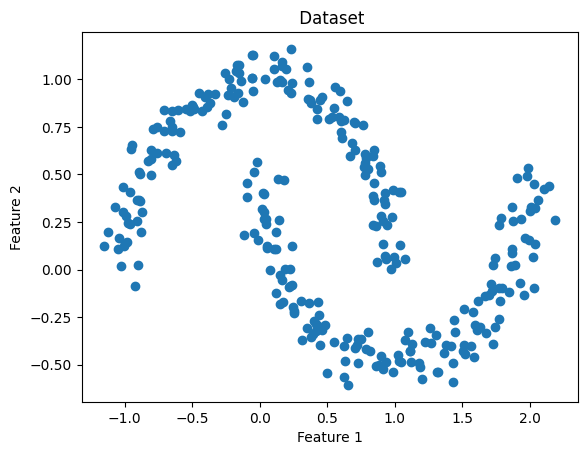

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# generate a non-spherical dataset
X, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

# visualize dataset
plt.scatter(X[:,0], X[:,1])
plt.title(" Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [5]:
from math import sqrt

# find all points within distance eps of a given point
def region_query(X, point_idx, eps):
    neighbors = []
    for i in range(len(X)):
        distance = np.linalg.norm(X[point_idx] - X[i])
        if distance <= eps:
            neighbors.append(i)
    return neighbors

In [6]:
# region_query
neighbors = region_query(X, 0, eps=0.2)
print(f"Point 0 has {len(neighbors)} neighbors within eps=0.2 → {neighbors[:10]}")

Point 0 has 14 neighbors within eps=0.2 → [0, 17, 34, 119, 160, 171, 180, 203, 205, 222]


In [7]:
# Expands a new cluster from the seed point using DBSCAN logic
def expand_cluster(X, labels, point_idx, cluster_id, eps, min_samples):
    neighbors = region_query(X, point_idx, eps)
    if len(neighbors) < min_samples:
        labels[point_idx] = -1  # Mark as noise
        return False

    # Assign cluster to seed point and all neighbors
    labels[point_idx] = cluster_id
    i = 0
    while i < len(neighbors):
        n_idx = neighbors[i]
        if labels[n_idx] == -1:
            labels[n_idx] = cluster_id
        elif labels[n_idx] == 0:
            labels[n_idx] = cluster_id
            n_neighbors = region_query(X, n_idx, eps)
            if len(n_neighbors) >= min_samples:
                neighbors.extend(n_neighbors)
        i += 1
    return True

In [8]:
labels = np.zeros(len(X))
expand_cluster(X, labels, 0, cluster_id=1, eps=0.2, min_samples=5)
print("Cluster labels after expansion:", np.unique(labels))

Cluster labels after expansion: [0. 1.]


In [9]:
def dbscan(X, eps, min_samples):
    labels = np.zeros(len(X))
    cluster_id = 0

    for i in range(len(X)):
        if labels[i] != 0:  # Already processed
            continue
        if expand_cluster(X, labels, i, cluster_id + 1, eps, min_samples):
            cluster_id += 1

    return labels

In [10]:
labels_scratch = dbscan(X, eps=0.2, min_samples=5)
print("Unique cluster IDs (from scratch):", np.unique(labels_scratch))

Unique cluster IDs (from scratch): [1. 2.]


In [11]:
from sklearn.cluster import DBSCAN as SK_DBSCAN

model = SK_DBSCAN(eps=0.2, min_samples=5)
labels_sklearn = model.fit_predict(X)

print("Unique cluster IDs (Scikit-learn):", np.unique(labels_sklearn))


Unique cluster IDs (Scikit-learn): [0 1]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


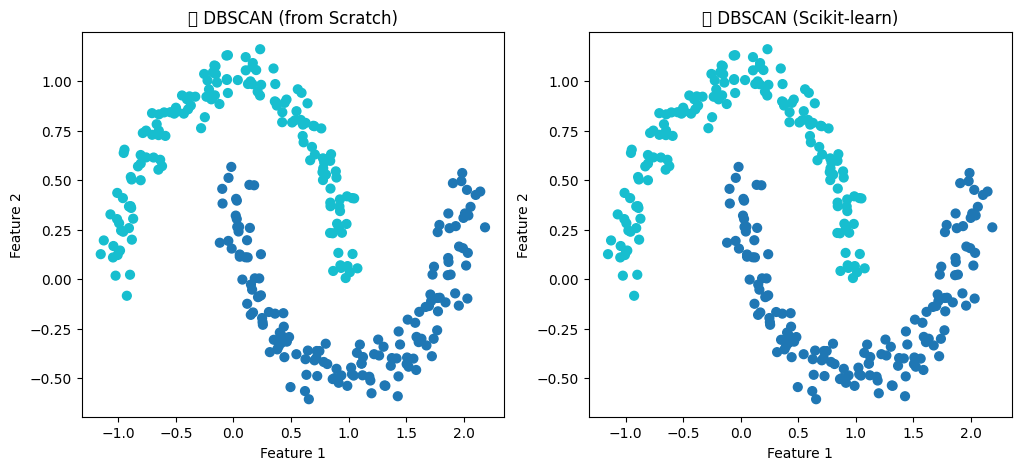

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Scratch Implementation
axes[0].scatter(X[:,0], X[:,1], c=labels_scratch, cmap='tab10', s=40)
axes[0].set_title("🧩 DBSCAN (from Scratch)")

# Scikit-learn Implementation
axes[1].scatter(X[:,0], X[:,1], c=labels_sklearn, cmap='tab10', s=40)
axes[1].set_title("🤖 DBSCAN (Scikit-learn)")

for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.show()